In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [3]:
drhos = np.load('/Users/paullab/codes/firm3d_fork_10132025/firm3d/examples/uniform_vol_distribution/dRhoPerPitchData2/drhos.npy')


Bc_res = 20
# modBmin_global = 5.515158152204317+0.5
# modBmax_global = 7.375629705430016-0.5
modBmin_global = 6.05
modBmax_global = 6.8
Bcs = np.linspace(modBmin_global,modBmax_global,Bc_res)

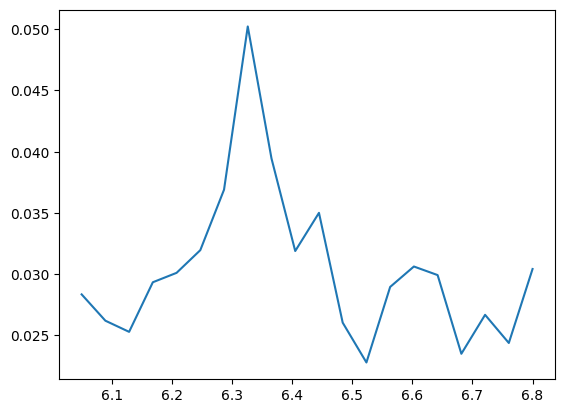

In [4]:
fig,ax = plt.subplots()
ax.plot(Bcs,drhos)

In [24]:
dp = 'dRhoPerEquilData3/'
descQA = np.load(dp+'desc_out_QA.npy',allow_pickle=True)
descQH = np.load(dp+'desc_out_QH.npy',allow_pickle=True)
descQI = np.load(dp+'desc_out_QI.npy',allow_pickle=True)
dQA_out = []
for dQA in descQA.item():
    dQA_out.append(descQA.item()[dQA]['f_tr2_desc'])
dQH_out = []
for dQH in descQH.item():
    dQH_out.append(descQH.item()[dQH]['f_tr2_desc'])
dQI_out = []
for dQI in descQI.item():
    dQI_out.append(descQI.item()[dQI]['f_tr2_desc'])

firm3dQA = np.load(dp+'drhosQA_uniformed.npy',allow_pickle=True)
firm3dQH = np.load(dp+'drhosQH_uniformed.npy',allow_pickle=True)
firm3dQI = np.load(dp+'drhosQI_uniformed.npy',allow_pickle=True)

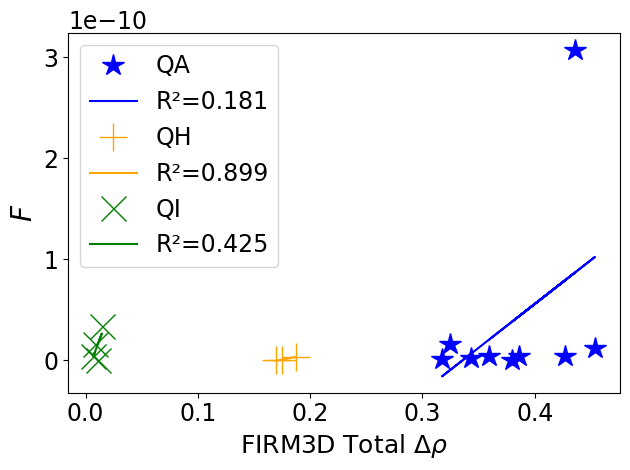

In [59]:
fig,ax = plt.subplots()
ax.plot(firm3dQA,dQA_out,'*',label='QA',color='blue',markersize=16)

# ---- compute linear fit ----
coeffs = np.polyfit(firm3dQA, dQA_out, 1)   # 1 = linear
m, b = coeffs

# predicted values
y_pred = m * firm3dQA + b

# ---- compute R^2 ----
ss_res = np.sum((dQA_out - y_pred)**2)
ss_tot = np.sum((dQA_out - np.mean(dQA_out))**2)
r2 = 1 - ss_res/ss_tot

# ---- plot trendline ----
ax.plot(firm3dQA, y_pred, label=f"R²={r2:.3f}",color='blue')



ax.plot(firm3dQH,dQH_out,'+',label='QH',color='orange',markersize=20)
# ---- compute linear fit ----
coeffs = np.polyfit(firm3dQH, dQH_out, 1)   # 1 = linear
m, b = coeffs

# predicted values
y_pred = m * firm3dQH + b

# ---- compute R^2 ----
ss_res = np.sum((dQH_out - y_pred)**2)
ss_tot = np.sum((dQH_out - np.mean(dQH_out))**2)
r2 = 1 - ss_res/ss_tot

# ---- plot trendline ----
ax.plot(firm3dQH, y_pred, label=f"R²={r2:.3f}",color='orange')





ax.plot(firm3dQI,dQI_out,'x',label='QI',color='g',markersize=18)
# ---- compute linear fit ----
coeffs = np.polyfit(firm3dQI, dQI_out, 1)   # 1 = linear
m, b = coeffs

# predicted values
y_pred = m * firm3dQI + b

# ---- compute R^2 ----
ss_res = np.sum((dQI_out - y_pred)**2)
ss_tot = np.sum((dQI_out - np.mean(dQI_out))**2)
r2 = 1 - ss_res/ss_tot

# ---- plot trendline ----
ax.plot(firm3dQI, y_pred, label=f"R²={r2:.3f}",color='g')

ax.tick_params(axis='y', labelsize=17)
ax.tick_params(axis='x', labelsize=17)

ax.yaxis.get_offset_text().set_fontsize(17)

ax.set_xlabel(r'FIRM3D Total $\Delta \rho$',fontsize=18)
ax.set_ylabel(r'$\mathbf{\mathit{F}}$',fontsize=20)
ax.legend(fontsize=17)
plt.tight_layout()
plt.savefig('multieq.pdf')

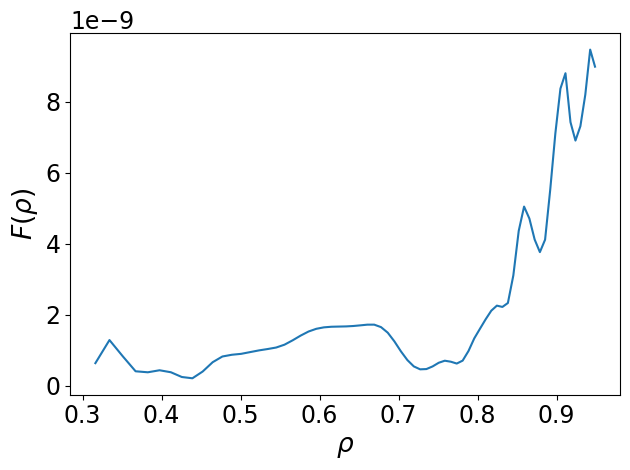

In [74]:
f_tr = np.load('rhosmoothness.npy',allow_pickle=True)
rhos = np.sqrt(np.linspace(0.1,0.9,70)) # rho = sqrt(s)
f_tr_perrho = f_tr.item()['f_rho']

fig,ax = plt.subplots()
ax.plot(rhos,f_tr_perrho)
ax.set_xlabel(r'$\rho$',fontsize=19)
ax.set_ylabel(r'$F(\rho)$',fontsize=19)
ax.tick_params(axis='y', labelsize=17)
ax.tick_params(axis='x', labelsize=17)

ax.yaxis.get_offset_text().set_fontsize(17)
plt.tight_layout()
plt.savefig('rhosmoothness.pdf')